# Create plots and tables
This notebook (as the name suggests) creates all final plots in the paper.

In [1]:
import glob
import os
import pickle
import re
import time

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import PercentFormatter

import seaborn as sns
from tqdm import tqdm
import numpy as np
import pandas as pd

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2) 

In [2]:
in_dir = "./"
plot_dir = "./"

eakf_metrics_df = pd.read_csv(in_dir + 'eakf_metrics_all.csv')
last_epi_days_df = pd.read_csv("compute_days.csv")
param_df = pd.read_csv("../params/param_list.csv")

## Table 2 and 3
This section prints out LaTeX code that can be copied into the overleaf file for tables 2 and 3.

In [3]:
def compute_ci(df, by_col):
    
    mean_df = df.groupby(by_col).mean()
    median_df = df.groupby(by_col).median()
    std_df = df.groupby(by_col).std()
    n_df = df.groupby(by_col).count()

    lower_df = df.groupby(by_col).quantile(q=0.025)
    upper_df = df.groupby(by_col).quantile(q=0.975)
    
    # add suffixes
    lower_df = lower_df.add_suffix('_lower')
    upper_df = upper_df.add_suffix('_upper')
    mean_df = mean_df.add_suffix('_mean')
    median_df = median_df.add_suffix('_median')
    # merge
    merge_df = lower_df.merge(mean_df, on=by_col)
    merge_df = merge_df.merge(upper_df, on=by_col)
    merge_df = merge_df.merge(median_df, on=by_col)
    
    return merge_df

def dataframe_to_latex(df, columns, titles, metric_dict=None, degree=2):
    """
    Convert a Pandas DataFrame with mean, lower, and upper columns to a LaTeX table.

    Parameters:
    - df: Pandas DataFrame.
    - columns: Columns of table.

    Returns:
    - LaTeX table string.
    """
    df = df[list(titles.keys())]
    # Column row
    tab_arg = "l|" * len(columns)
    latex_table = "\ begin{tabular}{|" + tab_arg + "} \hline "
    latex_table += " & ".join([titles[col] for col in df.columns])
    latex_table += " \\\\\n \hline "
    # Data rows
    for metric, title in metric_dict.items():
        latex_table += f"{title} & "
        mean = df.loc[df.metric == metric + "_mean"].round(degree).values.tolist()[0]
        lower = df.loc[df.metric == metric + "_lower"].round(degree).values.tolist()[0]
        upper = df.loc[df.metric == metric + "_upper"].round(degree).values.tolist()[0]
        median = df.loc[df.metric == metric + "_median"].round(degree).values.tolist()[0]
        latex_table += " &  ".join(
            [f"{mean[i]} ({lower[i]}, {upper[i]}) " for i in range(1,len(mean))]
        )
        latex_table += " \\\\\n \hline "
    
    latex_table += "\end{tabular}"

    return latex_table

In [4]:
eakf_stats_df = compute_ci(eakf_metrics_df, "method")

cols_for_table1 = ['metric', 'no inflation', 'fixed inflation', 'adaptive inflation', 'smooth inflation']

metric_title_dict = {
    # 'in_ci_last_epi_day' : 'True $R_t$ within 95\% CI',
    'rt_rmse_up_to_last_epi_day' : '$R_t$ RMSE',
    'avg_w2_up_to_last_epi_day' : '$W_2(p,q)$',
    'avg_kl_up_to_last_epi_day' : '$D_{KL}(p || q)$',
    'crps_up_to_last_epi_day' : 'CRPS',
}
metric_title_first_dict = {
    # 'in_ci_first_epi_day' : 'True $R_t$ within 95\% CI',
    'rt_rmse_up_to_first_epi_day' : '$R_t$ RMSE',
    'avg_w2_up_to_first_epi_day' : '$W_2(p,q)$',
    'avg_kl_up_to_first_epi_day' : '$D_{KL}(p || q)$',
    'crps_up_to_first_epi_day' : 'CRPS',
}
col_title_dict = {
    'metric' : 'Metric',
    'no inflation' : 'no inflation',
    'fixed inflation' : 'fixed inflation',
    'adaptive inflation' : 'adaptive inflation',
    'smooth inflation' : 'EnSRS adaptive inflation', 
}

table_df = eakf_stats_df.T.reset_index().rename(columns={'index':'metric'})

# table 1
print(dataframe_to_latex(table_df, cols_for_table1, col_title_dict, metric_title_dict))

# table 2
print(dataframe_to_latex(table_df, cols_for_table1, col_title_dict, metric_title_first_dict))

\ begin{tabular}{|l|l|l|l|l|} \hline Metric & no inflation & fixed inflation & adaptive inflation & EnSRS adaptive inflation \\
 \hline $R_t$ RMSE & 1.17 (0.67, 1.88)  &  0.53 (0.24, 1.28)  &  0.39 (0.24, 0.75)  &  0.19 (0.09, 0.51)  \\
 \hline $W_2(p,q)$ & 0.86 (0.4, 1.29)  &  0.74 (0.29, 1.16)  &  0.52 (0.26, 0.82)  &  0.34 (0.18, 0.69)  \\
 \hline $D_{KL}(p || q)$ & 6.6 (2.19, 11.48)  &  2.9 (0.37, 7.76)  &  0.81 (0.27, 2.21)  &  0.86 (0.3, 3.63)  \\
 \hline CRPS & 186.33 (78.91, 328.76)  &  92.63 (19.09, 296.69)  &  34.78 (17.37, 69.62)  &  61.91 (30.24, 120.13)  \\
 \hline \end{tabular}
\ begin{tabular}{|l|l|l|l|l|} \hline Metric & no inflation & fixed inflation & adaptive inflation & EnSRS adaptive inflation \\
 \hline $R_t$ RMSE & 0.27 (0.19, 0.4)  &  0.31 (0.24, 0.41)  &  0.36 (0.27, 0.54)  &  0.11 (0.06, 0.21)  \\
 \hline $W_2(p,q)$ & 0.62 (0.29, 0.98)  &  0.55 (0.3, 0.84)  &  0.52 (0.29, 0.77)  &  0.3 (0.2, 0.41)  \\
 \hline $D_{KL}(p || q)$ & 1.24 (0.47, 2.64)  &  0.83 (0.34

In [5]:
table_df.loc[table_df.metric.isin([k + '_mean' for k in list(metric_title_first_dict.keys())]), cols_for_table1]

method,metric,no inflation,fixed inflation,adaptive inflation,smooth inflation
9,rt_rmse_up_to_first_epi_day_mean,0.27,0.31,0.36,0.11
11,crps_up_to_first_epi_day_mean,38.52,36.16,31.72,59.46
13,avg_kl_up_to_first_epi_day_mean,1.24,0.83,0.66,0.83
15,avg_w2_up_to_first_epi_day_mean,0.62,0.55,0.52,0.30


In [6]:
table_df.loc[table_df.metric.isin([k + '_mean' for k in list(metric_title_dict.keys())]), cols_for_table1]

method,metric,no inflation,fixed inflation,adaptive inflation,smooth inflation
10,rt_rmse_up_to_last_epi_day_mean,1.17,0.53,0.39,0.19
12,crps_up_to_last_epi_day_mean,186.33,92.63,34.78,61.91
14,avg_kl_up_to_last_epi_day_mean,6.60,2.90,0.81,0.86
16,avg_w2_up_to_last_epi_day_mean,0.86,0.74,0.52,0.34


## Figure 1

In [7]:
def open_pickle_rt(pickle_file, smooth=False, plot_dir="/ifs/scratch/jls106_gp/nhw2114/data/example_plots_for_paper/"):
    with open(f"{plot_dir}/{pickle_file}", 'rb') as file:
        data = pickle.load(file)
    if smooth:
        array = np.array([θ.beta*θ.t_I for θ in data.θ_lag_list])
    else:
        array = np.array([θ.beta*θ.t_I for θ in data.θ_list])
    return array

def open_pickle_data(pickle_file, smooth=False, plot_dir="/ifs/scratch/jls106_gp/nhw2114/data/example_plots_for_paper/"):
    with open(f"{plot_dir}/{pickle_file}", 'rb') as file:
        data = pickle.load(file)
    array = np.array([x.i for x in data.x_list])
    data = data.data.i
    return array, data

def compute_ci_mean(array, confidence_level=95):
    ci = np.percentile(array, [100 - confidence_level, confidence_level], axis=1)
    mean = np.mean(array, axis=1)
    return ci, mean

def get_truth(pickle_file, plot_dir="/ifs/scratch/jls106_gp/nhw2114/data/example_plots_for_paper/"):
    with open(f"{plot_dir}/{pickle_file}", 'rb') as file:
        data = pickle.load(file)
    return data.data.rt

def get_true_data_distribution(pickle_file, plot_dir="./"):
    with open(f"{plot_dir}/{pickle_file}", 'rb') as file:
        data = pickle.load(file)
    return data.data.data_distribution
        
def get_kf_obj(pickle_file, smooth=False, plot_dir="./"):
    with open(f"{plot_dir}/{pickle_file}", 'rb') as file:
        data = pickle.load(file)
    return data

In [8]:
avg_rmse_param = 45181
run = 0

kf_adapt_obj = get_kf_obj(f"{plot_dir}/{avg_rmse_param}_adaptive_inflation_run_{run}.pkl")

In [18]:
def plot_rt_posterior(pp, last_plot_day=None, save=False, fname=None):
    first_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'first_epi_day'].values[0]
    last_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'last_epi_day'].values[0]
    
    for run in range(1):
        no_pickle_file = f"{pp}_no_inflation_run_{run}.pkl"
        fixed_pickle_file = f"{pp}_fixed_inflation_run_{run}.pkl"
        adapt_pickle_file = f"{pp}_adaptive_inflation_run_{run}.pkl"
        smooth_pickle_file = f"{pp}_smooth_inflation_run_{run}.pkl"

        # get rt estimates and truth
        truth = get_truth(no_pickle_file, plot_dir=plot_dir)
        ci_no, mean_no = compute_ci_mean(open_pickle_rt(no_pickle_file, plot_dir=plot_dir))
        ci_fixed, mean_fixed = compute_ci_mean(open_pickle_rt(fixed_pickle_file, plot_dir=plot_dir))
        ci_adapt, mean_adapt = compute_ci_mean(open_pickle_rt(adapt_pickle_file, plot_dir=plot_dir))
        ci_smooth, mean_smooth = compute_ci_mean(open_pickle_rt(smooth_pickle_file, plot_dir=plot_dir, smooth=True))

        i_no, i_obs = open_pickle_data(no_pickle_file, plot_dir=plot_dir)
        ci_i_no, mean_i_no = compute_ci_mean(i_no)
        i_fixed, _ = open_pickle_data(fixed_pickle_file, plot_dir=plot_dir)
        ci_i_fixed, mean_i_fixed = compute_ci_mean(i_fixed)
        i_adapt, _ = open_pickle_data(adapt_pickle_file, plot_dir=plot_dir)
        ci_i_adapt, mean_i_adapt = compute_ci_mean(i_adapt)
        i_smooth, _ = open_pickle_data(smooth_pickle_file, plot_dir=plot_dir)
        ci_i_smooth, mean_i_smooth = compute_ci_mean(i_smooth)
        
        if last_plot_day:
            mean_no       = mean_no[:last_plot_day]
            mean_fixed    = mean_fixed[:last_plot_day]
            mean_adapt    = mean_adapt[:last_plot_day]
            mean_smooth   = mean_smooth[:last_plot_day]
            
            ci_no     = ci_no[:,:last_plot_day]
            ci_fixed  = ci_fixed[:,:last_plot_day]
            ci_adapt  = ci_adapt[:,:last_plot_day]
            ci_smooth = ci_smooth[:,:last_plot_day]
            
            truth = truth[:last_plot_day]
            
            mean_i_no       = mean_i_no[:last_plot_day]
            mean_i_fixed    = mean_i_fixed[:last_plot_day]
            mean_i_adapt    = mean_i_adapt[:last_plot_day]
            mean_i_smooth   = mean_i_smooth[:last_plot_day]
            
            ci_i_no     = ci_i_no[:,:last_plot_day]
            ci_i_fixed  = ci_i_fixed[:,:last_plot_day]
            ci_i_adapt  = ci_i_adapt[:,:last_plot_day]
            ci_i_smooth = ci_i_smooth[:,:last_plot_day]
        
        fig, ax = plt.subplots()
        fig.suptitle(r"$R_0(t)$ posterior distribution")
        fig.set_figheight(6)
        fig.set_figwidth(8)
        
        # plot Rt
        ax.fill_between(np.arange(ci_no.shape[1]), ci_no[0,:], ci_no[1,:], color='dodgerblue', alpha=0.3)
        ax.plot(mean_no, color="dodgerblue", label=r"EAKF with no inflation")

        ax.fill_between(np.arange(ci_fixed.shape[1]), ci_fixed[0,:], ci_fixed[1,:], color='purple', alpha=0.3)
        ax.plot(mean_fixed, color="purple", label=r"EAKF with fixed inflation")

        ax.fill_between(np.arange(ci_adapt[0,:].shape[0]), ci_adapt[0,:], ci_adapt[1,:], color='goldenrod', alpha=0.3)
        ax.plot(mean_adapt, color="goldenrod", label=r"EAKF with adaptive inflation")

        ax.fill_between(np.arange(ci_smooth.shape[1]), ci_smooth[0,:], ci_smooth[1,:], color='seagreen', alpha=0.3)
        ax.plot(mean_smooth, color="seagreen", label=r"EnSRS (smoothing) with adaptive inflation")

        ax.plot(truth, color="firebrick", lw=1.5, linestyle='dashed', label=r"Synthetic truth")
            

        ax.set_xlabel("day", fontsize=12)
        ax.set_ylabel(r"$R_0(t)$", fontsize=12)

        ax.grid(linestyle='dotted')
        
        # add minor ticks for first and last epi day
        extraticks = [first_day, last_day]
        loc = matplotlib.ticker.FixedLocator(extraticks)
        ax.xaxis.set_minor_locator(loc)
        ax.grid(which='minor', color='red', linestyle='dotted')

        ax.legend(loc='upper right')
        
        fig.tight_layout()
        
        if save:
            if not fname:
                fname = f"eakf_{pp}_rt_posterior"
            print(f"saving to {plot_dir}/{fname}")
            plt.savefig(f"{fname}.pdf", bbox_inches='tight', transparent=True)
            plt.savefig(f"{fname}.png", bbox_inches='tight', dpi=300)
        
        plt.show()

45181
saving to .//fig1


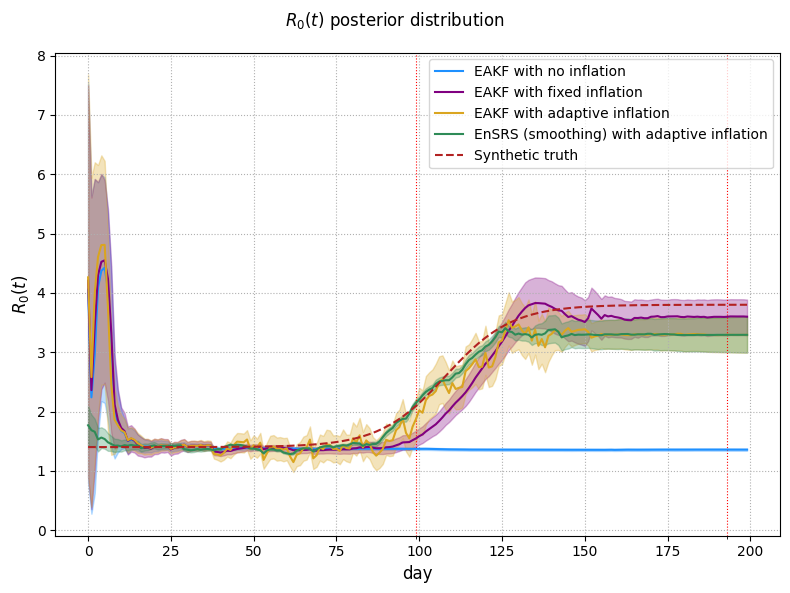

In [19]:
print(avg_rmse_param)
avg_rmse_param = int(avg_rmse_param)
plot_rt_posterior(avg_rmse_param, 200, save=True, fname="fig1")

### Table 1 - Caption

In [11]:
first_day = last_epi_days_df.loc[last_epi_days_df.param == avg_rmse_param, 'first_epi_day'].values[0]
last_day = last_epi_days_df.loc[last_epi_days_df.param == avg_rmse_param, 'last_epi_day'].values[0]

beta_0 = round(param_df.iloc[avg_rmse_param]["rt_0"] / param_df.iloc[avg_rmse_param]["t_I"], 2)
beta_1 = round(param_df.iloc[avg_rmse_param]["rt_1"] / param_df.iloc[avg_rmse_param]["t_I"], 2)
tmid = int(param_df.iloc[avg_rmse_param]["midpoint"])
k = int(param_df.iloc[avg_rmse_param]["k"])


caption = fr"The posterior mean of each method is presented with 95\% CrI, represented by the shaded region. \
The beginning and end of the second epidemic,  indicated by the vertical dotted red lines, are day {first_day} and day {last_day}. \
The sigmoid parameters for this example were $\beta_0 = {beta_0}$, $\beta_1 = {beta_1}$, $tmid = {tmid}$, $k = {k}$."
print(caption)

The posterior mean of each method is presented with 95\% CrI, represented by the shaded region. \
The beginning and end of the second epidemic,  indicated by the vertical dotted red lines, are day 99 and day 193. \
The sigmoid parameters for this example were $\beta_0 = 0.35$, $\beta_1 = 0.95$, $tmid = 108$, $k = 0$.


## Figure 2

saving to .//fig2


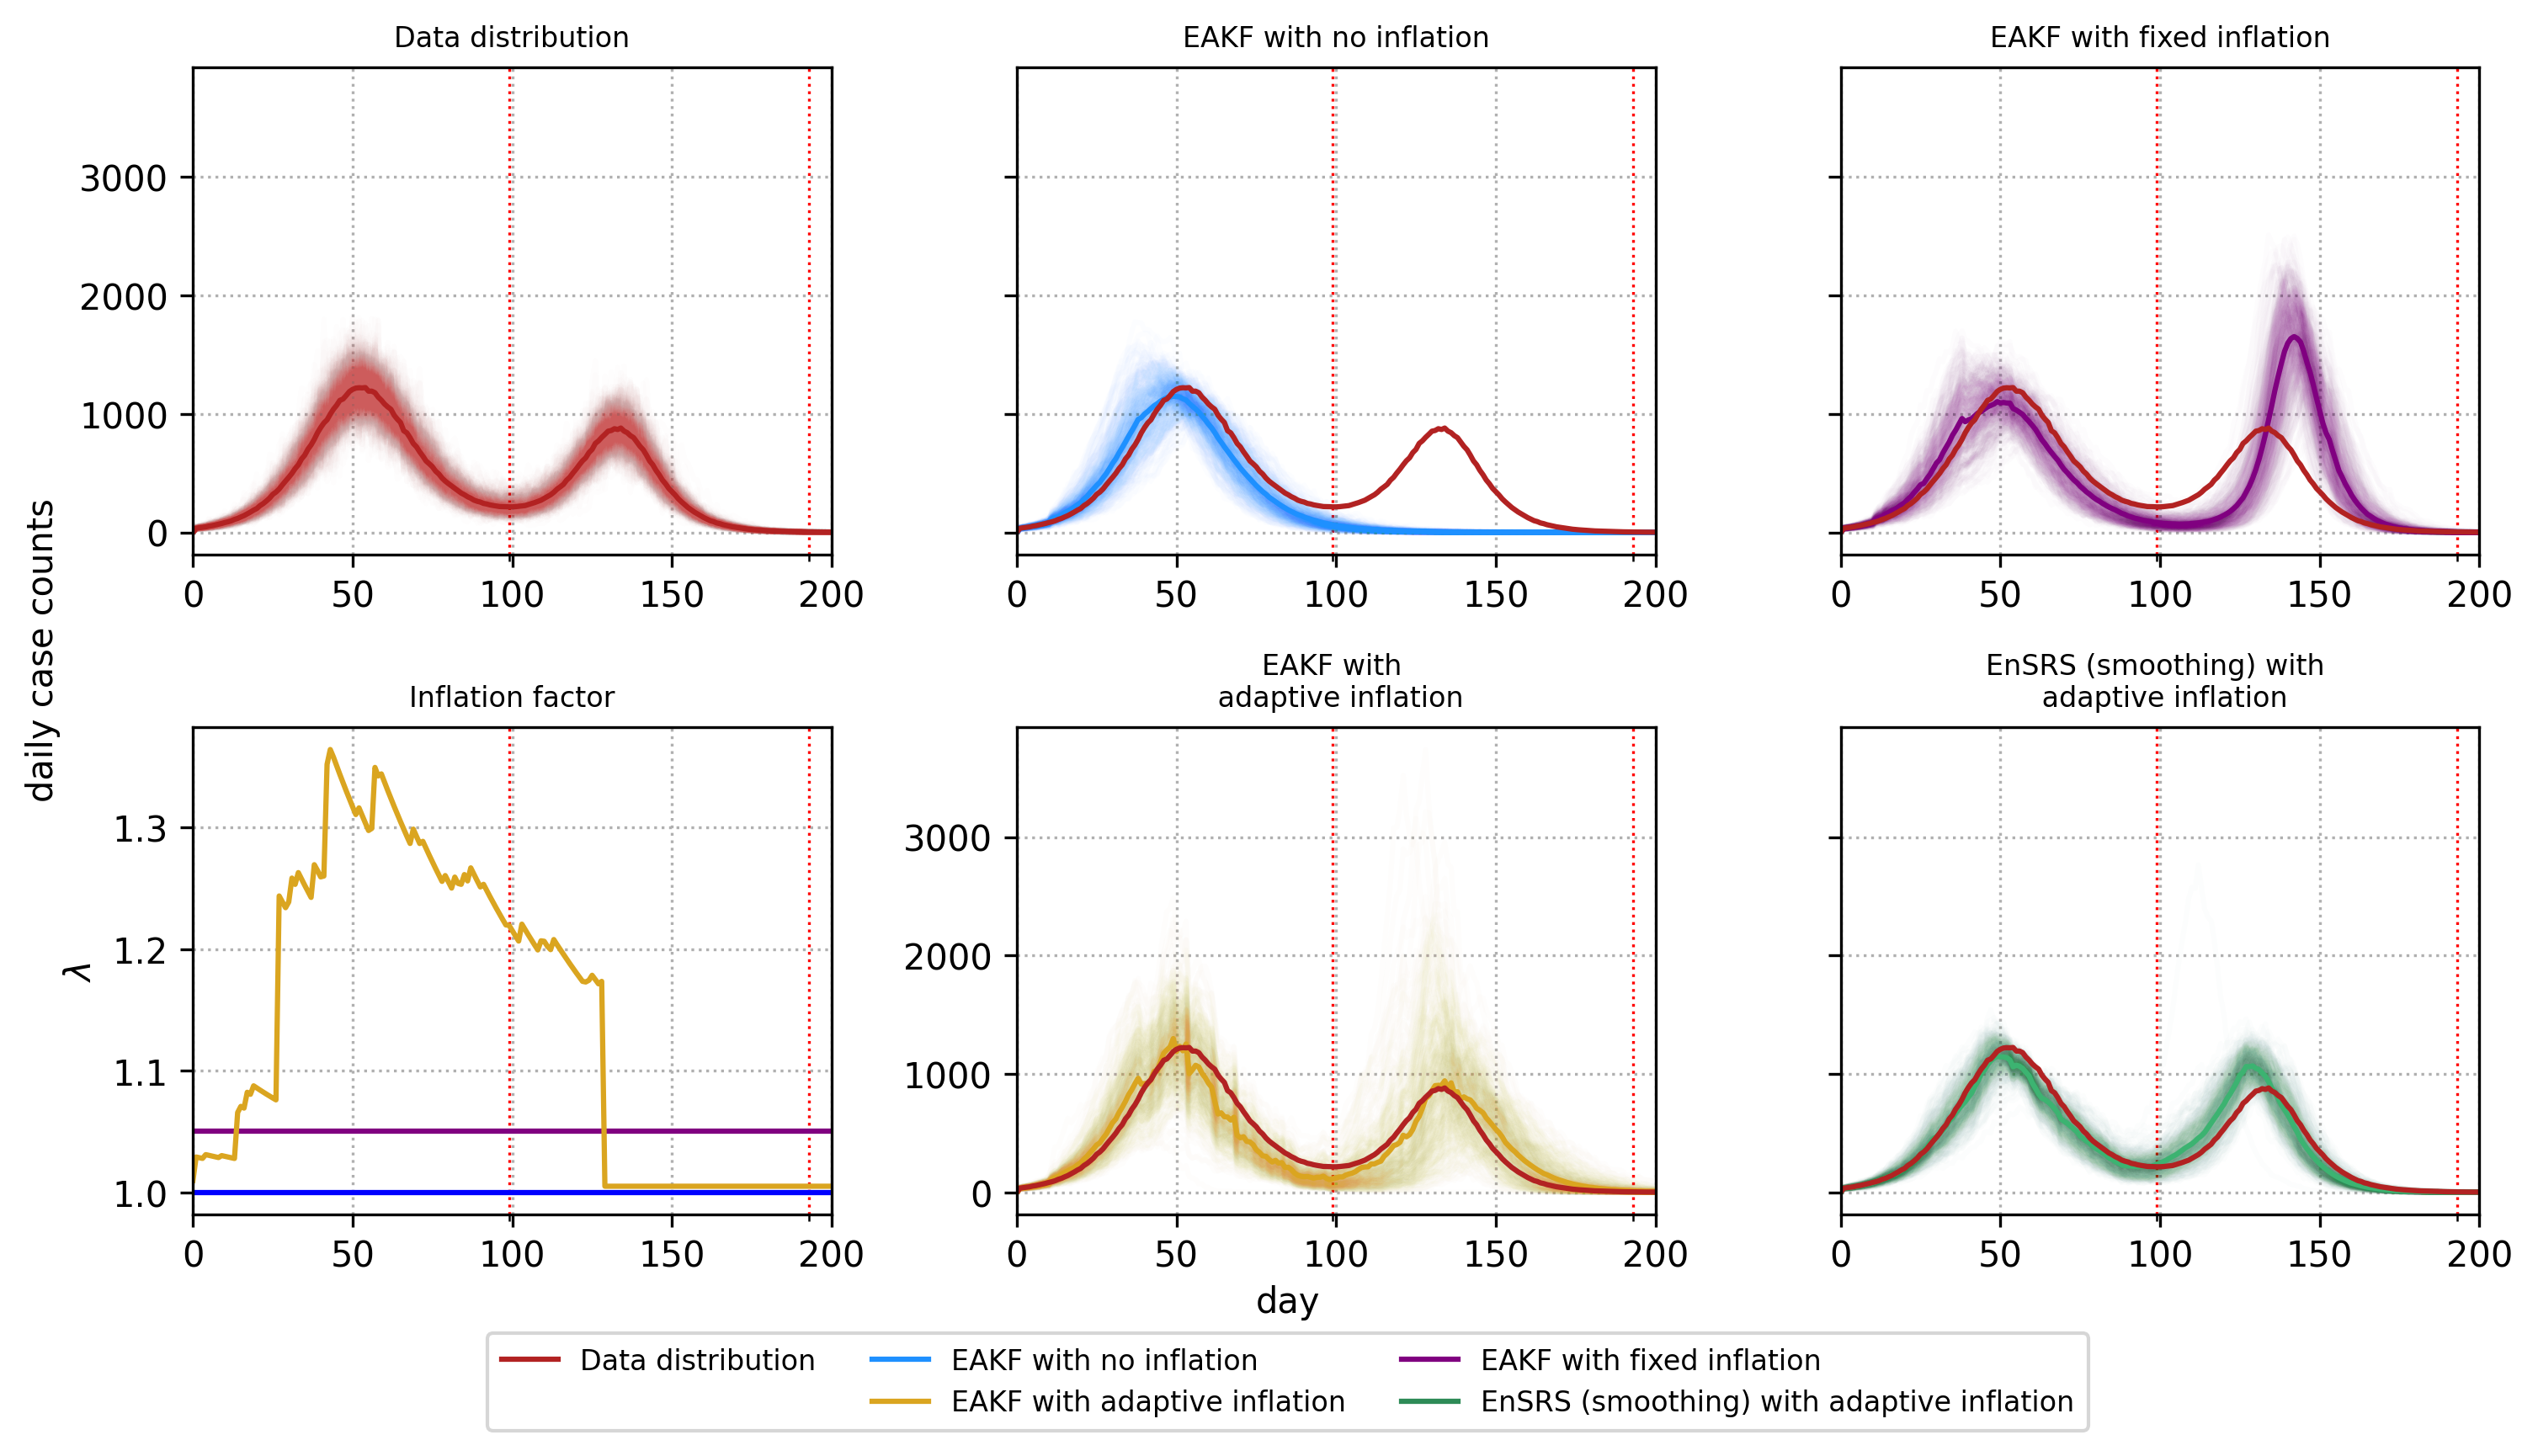

In [20]:
def plot_ppd_no_epifilter(pp, plot_dir, save=False, run=0, fname=None):
    # last_day = last_day_df.loc[last_day_df.param == pp, 'last_epidemic_day'].values[0]
    fs = 8
    plot_end = 200

    no_pickle_file     = f"{pp}_no_inflation_run_{run}.pkl"
    fixed_pickle_file  = f"{pp}_fixed_inflation_run_{run}.pkl"
    adapt_pickle_file  = f"{pp}_adaptive_inflation_run_{run}.pkl"
    smooth_pickle_file = f"{pp}_smooth_inflation_run_{run}.pkl"
    
    first_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'first_epi_day'].values[0]
    last_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'last_epi_day'].values[0]
    
    kf_no = get_kf_obj(no_pickle_file)
    kf_fixed = get_kf_obj(fixed_pickle_file)
    kf_adapt = get_kf_obj(adapt_pickle_file)
    kf_smooth = get_kf_obj(smooth_pickle_file)
    truth = get_true_data_distribution(no_pickle_file)
    sample_cols = [f"sample{i}" for i in range(1, 301)]
    
    fig = plt.figure(figsize=(10, 5.25), dpi=300)
    gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])

    ax1 = plt.subplot(gs[0, 0])
    ax1.plot(truth, color="indianred", alpha=0.01)
    ax1.plot(np.mean(truth, axis=1), color='firebrick')
    ax1.set_title('Data distribution', fontsize=fs)

    ax2 = plt.subplot(gs[0,1], sharey=ax1)
    ax2.plot(kf_no.i_ppc, color="dodgerblue", alpha=0.01)
    ax2.plot(np.mean(kf_no.i_ppc, axis=1), color='dodgerblue')
    ax2.plot(np.mean(truth, axis=1), color='firebrick')
    ax2.set_title('EAKF with no inflation', fontsize=fs)
    plt.setp(ax2.get_yticklabels(), visible=False)

    ax3 = plt.subplot(gs[0,2], sharey=ax1)
    ax3.plot(kf_fixed.i_ppc, color="purple", alpha=0.01)
    ax3.plot(np.mean(kf_fixed.i_ppc, axis=1), color='purple')
    ax3.plot(np.mean(truth, axis=1), color='firebrick')
    ax3.set_title('EAKF with fixed inflation', fontsize=fs)
    plt.setp(ax3.get_yticklabels(), visible=False)

    ax4 = plt.subplot(gs[1,0])
    ax4.plot(kf_no.lam_list, color="blue")
    ax4.plot(kf_fixed.lam_list[0] * np.ones(len(kf_fixed.lam_list)), color="purple")
    ax4.plot(kf_adapt.lam_list, color='goldenrod')
    ax4.set_ylabel(r'$\lambda$')
    ax4.set_title('Inflation factor', fontsize=fs)

    ax5 = plt.subplot(gs[1,1], sharey=ax1)
    ax5.plot(kf_adapt.i_ppc, color="goldenrod", alpha=0.01)
    ax5.plot(np.mean(kf_adapt.i_ppc, axis=1), color='goldenrod')
    ax5.plot(np.mean(truth, axis=1), color='firebrick')
    ax5.set_title('EAKF with \n adaptive inflation', fontsize=fs)

    ax6 = plt.subplot(gs[1,2], sharey=ax1)
    ax6.plot(kf_smooth.i_ppc, color="seagreen", alpha=0.01)
    ax6.plot(np.mean(kf_smooth.i_ppc, axis=1), color='mediumseagreen')
    ax6.plot(np.mean(truth, axis=1), color='firebrick')
    ax6.set_title('EnSRS (smoothing) with \n adaptive inflation', fontsize=fs)
    plt.setp(ax6.get_yticklabels(), visible=False)
    
    
    ax1.grid(linestyle='dotted')
    ax2.grid(linestyle='dotted')
    ax3.grid(linestyle='dotted')
    ax4.grid(linestyle='dotted')
    ax5.grid(linestyle='dotted')
    ax6.grid(linestyle='dotted')

    plt.subplots_adjust(hspace = 0.5, wspace=0.3)
    fig.text(0, 0.5, 'daily case counts', va='center', rotation='vertical')
    fig.text(0.5, 0, 'day', ha='center')
    # plt.figtext(0.5, 0.71, 'Posterior predictive distributions', ha="center", va="top", fontsize=12)

    # add minor ticks for first and last epi day
    extraticks = [first_day, last_day]
    loc = matplotlib.ticker.FixedLocator(extraticks)
    for aa in [ax1, ax2, ax3, ax4, ax5, ax6]:
        aa.xaxis.set_minor_locator(loc)
        aa.grid(which='minor', color='red', linestyle='dotted')
        aa.set_xlim(0, plot_end)


    blank_line = mlines.Line2D([], [], color='none')
    red_line = mlines.Line2D([], [], color='firebrick', linestyle='-')
    blue_line = mlines.Line2D([], [], color='dodgerblue', linestyle='-')
    purple_line = mlines.Line2D([], [], color='purple', linestyle='-')
    yellow_line = mlines.Line2D([], [], color='goldenrod', linestyle='-')
    green_line = mlines.Line2D([], [], color='seagreen', linestyle='-')

    handles = [red_line, blank_line, blue_line, yellow_line, purple_line, green_line]
    labels = ['Data distribution', '', 'EAKF with no inflation', 'EAKF with adaptive inflation', 'EAKF with fixed inflation', 'EnSRS (smoothing) with adaptive inflation', 'EpiEstim', 'EpiFilter']
    # Place the legend outside the plots
    fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),  # Pushes legend below figure
           ncol=3,
           fontsize=fs,
           title_fontsize=9,
           frameon=True,
           borderpad=0.5
          )
    
    if save:
        if not fname:
            fname = f"eakf_{pp}_ppd"
        print(f"saving to {plot_dir}/{fname}")
        plt.savefig(f"{plot_dir}/{fname}.pdf", bbox_inches='tight', transparent=True)
        plt.savefig(f"{plot_dir}/{fname}.png", bbox_inches='tight', dpi=300)
    plt.tight_layout()
    plt.show()

plot_ppd_no_epifilter(avg_rmse_param, plot_dir=plot_dir, save=True, fname=f"fig2")

### Number plug paragraph for Fig 2

In [21]:
eakf_metrics_df.loc[
    eakf_metrics_df.param == avg_rmse_param,
    ['method', 'avg_kl_up_to_first_epi_day', 'avg_w2_up_to_first_epi_day', 'avg_kl_up_to_last_epi_day', 'avg_w2_up_to_last_epi_day']].round(2)

,method,avg_kl_up_to_first_epi_day,avg_w2_up_to_first_epi_day,avg_kl_up_to_last_epi_day,avg_w2_up_to_last_epi_day
26004,adaptive inflation,0.66,0.55,0.64,0.53
26005,fixed inflation,0.97,0.57,2.53,0.82
26006,no inflation,1.72,0.64,10.36,1.19
26007,smooth inflation,1.24,0.30,1.25,0.50


## Figure 3 - Distribution of performance metrics

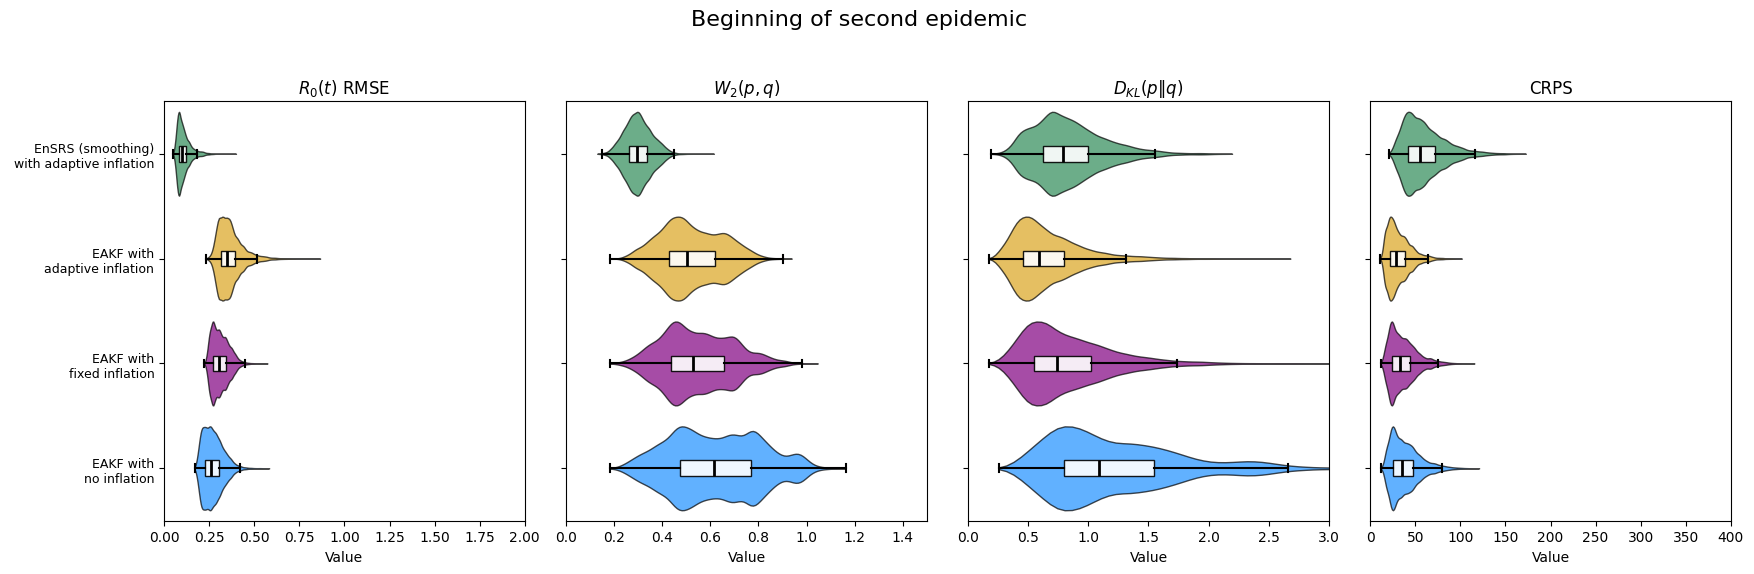

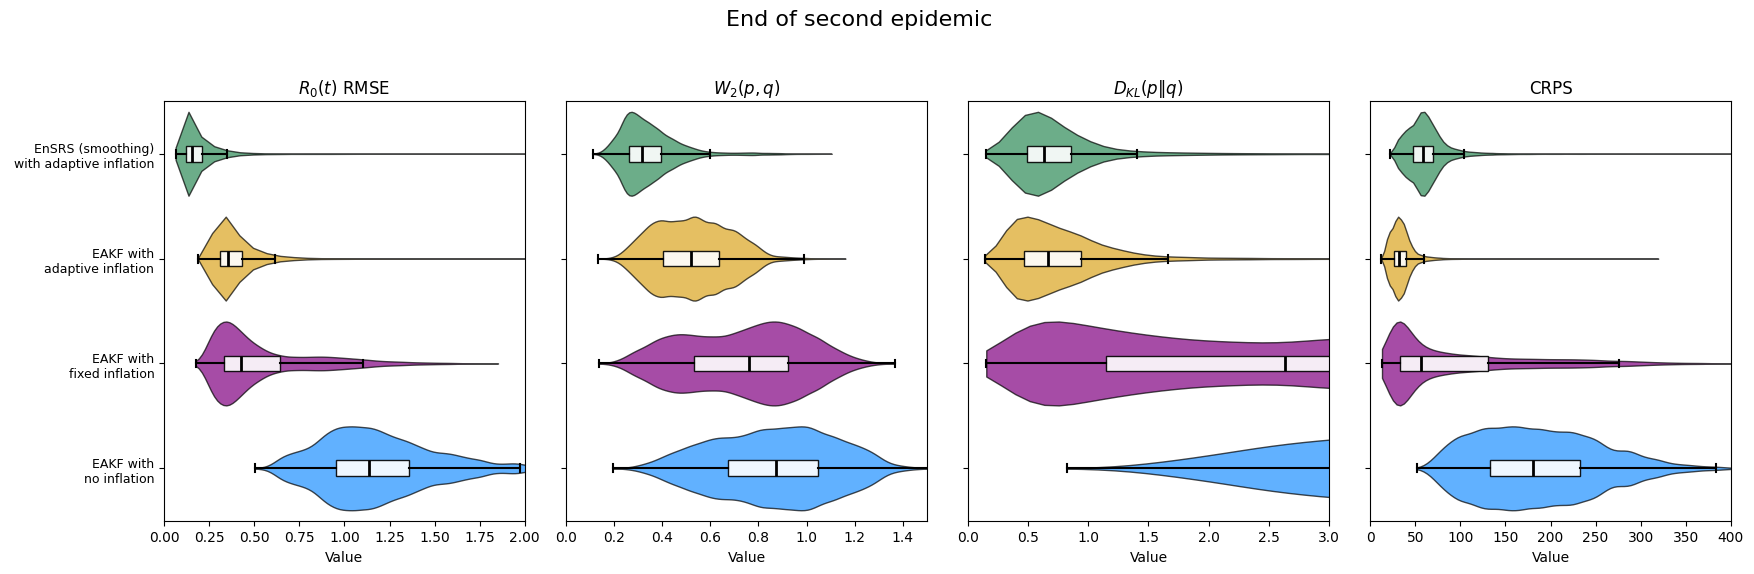

In [22]:
cols_titles = {
    'rt_rmse_up_to_first_epi_day' : (0, r'$R_0(t)$ RMSE'),
    'avg_w2_up_to_first_epi_day'  : (1, r'$W_2(p,q)$'),
    'avg_kl_up_to_first_epi_day'  : (2, r'$D_{KL}(p\|q)$'),
    'crps_up_to_first_epi_day'    : (3, 'CRPS'),
    'rt_rmse_up_to_last_epi_day' : (0, r'$R_0(t)$ RMSE'),
    'avg_w2_up_to_last_epi_day'  : (1, r'$W_2(p,q)$'),
    'avg_kl_up_to_last_epi_day'  : (2, r'$D_{KL}(p\|q)$'),
    'crps_up_to_last_epi_day'    : (3, 'CRPS')
}

methods = ["no inflation", "fixed inflation", "adaptive inflation", "smooth inflation"]
colors = ['dodgerblue', 'purple', 'goldenrod', 'seagreen', 'black', 'orangered']

limits = {
    'rt_rmse_up_to_first_epi_day' : (0,2),
    'avg_w2_up_to_first_epi_day'  : (0,1.5),
    'avg_kl_up_to_first_epi_day'  : (0,3),
    'crps_up_to_first_epi_day'    : (0,400),
    'rt_rmse_up_to_last_epi_day' : (0,2),
    'avg_w2_up_to_last_epi_day'  : (0,1.5),
    'avg_kl_up_to_last_epi_day'  : (0,3),
    'crps_up_to_last_epi_day'    : (0,400)
}

method_dict = {
    "no inflation" : r'EAKF with' '\n' 'no inflation',
    "fixed inflation": 'EAKF with' '\n' 'fixed inflation',
    "adaptive inflation" : 'EAKF with' '\n' ' adaptive inflation',
    "smooth inflation" : 'EnSRS (smoothing)' '\n' ' with adaptive inflation',
    "epiestim" : 'EpiEstim',
    "epifilter" : 'EpiFilter',
}


# Separate metrics for each figure
first_day_metrics_dict = {k: v for k, v in cols_titles.items() if "first_epi_day" in k}
last_day_metrics_dict = {k: v for k, v in cols_titles.items() if "last_epi_day" in k}

def create_figure_with_horizontal_violins(
    metrics_to_plot_dict, fig_title, methods_list, color_list,
    method_display_names, data_limits, eakf_df
    ):
    num_metrics = len(metrics_to_plot_dict)
    if num_metrics == 0:
        print(f"No metrics to plot for {fig_title}")
        return None, None

    fig_width = max(15, num_metrics * 4.5)
    fig_height = max(6, len(methods_list) * 0.8 + 2)

    fig, axes = plt.subplots(nrows=1, ncols=num_metrics, figsize=(fig_width, fig_height), sharey=True)
    if num_metrics == 1:
        axes = [axes]

    sorted_metric_tuples = sorted(metrics_to_plot_dict.items(), key=lambda item: item[1][0])

    for ax_idx, (metric_col_name, (_, metric_display_title)) in enumerate(sorted_metric_tuples):
        ax_to_plot = axes[ax_idx]
        
        datasets_for_this_metric = []
        colors_for_violin_bodies = []
        method_labels_for_this_plot = []

        for method_idx, method_name in enumerate(methods_list):
            data_series = None
            if method_name == "epiestim":
                if metric_col_name in epiestim_df.columns:
                    data_series = epiestim_df.loc[epiestim_df.window == 8, metric_col_name]
                else:
                    print(f"Metric '{metric_col_name}' not found in epiestim_df. Skipping for method '{method_name}'.")
            elif method_name == "epifilter":
                if metric_col_name in epifilter_df.columns:
                    data_series = epifilter_df[metric_col_name]
                else:
                    print(f"Metric '{metric_col_name}' not found in epifilter_df. Skipping for method '{method_name}'.")
            else:
                if metric_col_name in eakf_df.columns:
                    data_series = eakf_df.loc[eakf_df["method"] == method_name, metric_col_name]
                else:
                    print(f"Metric '{metric_col_name}' not found in eakf_df. Skipping for method '{method_name}'.")
            
            data = np.array([])
            if data_series is not None:
                if "in_ci" in metric_col_name: # Example handling for boolean-like data
                    data = data_series.astype(str).str.lower().map({'true': 1.0, 'false': 0.0, '1':1.0, '0':0.0, '1.0':1.0, '0.0':0.0}).values
                else:
                    data = data_series.values
                
                data = pd.to_numeric(data, errors='coerce')
                data = data[~np.isnan(data)]
                data = data[~np.isinf(data)]
            
            if data.size > 0:
                datasets_for_this_metric.append(data)
                colors_for_violin_bodies.append(color_list[method_idx])
                method_labels_for_this_plot.append(method_display_names[method_name])
            else:
                print(f"No valid data for method '{method_name}' in metric '{metric_col_name}'. Skipping for this subplot.")

        if not datasets_for_this_metric:
            ax_to_plot.text(0.5, 0.5, "No data for any method", horizontalalignment='center', verticalalignment='center', transform=ax_to_plot.transAxes)
            ax_to_plot.set_title(metric_display_title, fontsize=12)
            ax_to_plot.set_yticks([])
            ax_to_plot.set_xticks([])
            continue

        num_actual_datasets = len(datasets_for_this_metric)
        positions = np.arange(1, num_actual_datasets + 1)
        
        # Plot Violins
        quantiles_for_violin_CI = [[0.025, 0.975] for _ in range(num_actual_datasets)]

        vp = ax_to_plot.violinplot(datasets_for_this_metric,
                                   positions=positions,
                                   vert=False,
                                   showmeans=False,      # Means not shown on violin
                                   showmedians=False,    # Medians will be from boxplot
                                   showextrema=False,    # Extrema will be from boxplot whiskers
                                   widths=0.8,           # Width of the violins
                                   # quantiles=quantiles_for_violin_CI # Show 95% CI lines on violin
                                   )
        
        # Style violin bodies
        for i, pc in enumerate(vp['bodies']):
            pc.set_facecolor(colors_for_violin_bodies[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.7) # Make violins somewhat transparent
        
        # Style 95% CI quantile lines on the violin
        if 'cquantiles' in vp:
            vp['cquantiles'].set_color('dimgray') # A neutral color for these lines
            vp['cquantiles'].set_linestyle(':')  # Dotted lines
            vp['cquantiles'].set_linewidth(1.2)

        # Plot Boxplots inside Violins
        bp = ax_to_plot.boxplot(datasets_for_this_metric,
                                positions=positions,
                                vert=False,          # Horizontal
                                patch_artist=True,   # Needed to fill the box with color
                                showfliers=False,    # Hide outliers, violin shows full distribution
                                widths=0.15,         # Make boxes narrow to fit inside violins
                                medianprops={'color': 'black', 'linewidth': 2}, # Make median prominent
                                boxprops={'facecolor': 'white', 'edgecolor': 'black', 'alpha': 0.9}, # Solid white box
                                whiskerprops={'color': 'black', 'linewidth': 1.5, 'linestyle': '-'},
                                capprops={'color': 'black', 'linewidth': 1.5}
                               )

        ax_to_plot.set_title(metric_display_title, fontsize=12)
        ax_to_plot.set_xlabel("Value", fontsize=10)
        if metric_col_name in data_limits:
            ax_to_plot.set_xlim(data_limits[metric_col_name])
        else:
            print(f"Warning: No limit specified for metric '{metric_col_name}'. Autoscale will be used for x-axis.")
        
        ax_to_plot.set_yticks(positions)
        ax_to_plot.set_yticklabels(method_labels_for_this_plot, fontsize=9)

    fig.suptitle(fig_title, fontsize=16)
    fig.tight_layout(rect=[0.02, 0.03, 1, 0.95]) # Adjust rect for layout
    return fig, axes

# Fig 1 Beginning of second epidemic ---
fig1, _ = create_figure_with_horizontal_violins(
    metrics_to_plot_dict=first_day_metrics_dict,
    fig_title="Beginning of second epidemic",
    methods_list=methods,
    color_list=colors, # These are for violin bodies
    method_display_names=method_dict,
    data_limits=limits,
    eakf_df=eakf_metrics_df,
)
if fig1:
    fig1.savefig(f"{plot_dir}/fig3a.pdf", bbox_inches='tight', transparent=True)
    fig1.savefig(f"{plot_dir}/fig3a.png", bbox_inches='tight', dpi=300)

# Fig 2
fig2, _ = create_figure_with_horizontal_violins(
    metrics_to_plot_dict=last_day_metrics_dict,
    fig_title="End of second epidemic",
    methods_list=methods,
    color_list=colors, # These are for violin bodies
    method_display_names=method_dict,
    data_limits=limits,
    eakf_df=eakf_metrics_df,
)
if fig2:
    fig2.savefig(f"{plot_dir}/fig3b.pdf", bbox_inches='tight', transparent=True)
    fig2.savefig(f"{plot_dir}/fig3b.png", bbox_inches='tight', dpi=300)

if fig1 or fig2:
    plt.show()
else:
    print("No figures were generated. Check for missing data or metrics.")

### Plot for one parameter scenario

In [15]:
in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240727_run_kl_w2_day/"
epiestim_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240827_epiestim_rmse_crps_reliability_day_rerun2/"

rmse_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240818_run_rmse_crps_inci_fix"
rmse_epiestim_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240827_epiestim_rmse_crps_reliability_day_rerun2"

df = pd.read_csv(f"{in_dir}/{avg_rmse_param}_eakf_metrics.csv").reset_index()
epiestim_df = pd.read_csv(f"{epiestim_in_dir}/{avg_rmse_param}_epiEstim_kl_w2.csv")

rmse_df = pd.read_csv(f"{rmse_in_dir}/{avg_rmse_param}_eakf_metrics.csv").reset_index()
rmse_epiestim_df = pd.read_csv(f"{rmse_epiestim_in_dir}/{avg_rmse_param}_epiEstim_rmse_crps_reliability.csv")

pp = avg_rmse_param

fig, ax = plt.subplots(4, sharex=True)
fig.set_figheight(10)
fig.set_figwidth(8)

first_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'first_epi_day'].values[0]
last_day = last_epi_days_df.loc[last_epi_days_df.param == pp, 'last_epi_day'].values[0]

# avg kl
ax[0].plot(df.loc[df.method == "no inflation", "day"], df.loc[df.method == "no inflation", "avg_kl"].expanding().mean(), color="dodgerblue", label=r"EAKF with no inflation")
ax[0].plot(df.loc[df.method == "fixed inflation", "day"], df.loc[df.method == "fixed inflation", "avg_kl"].expanding().mean(), color="purple", label=r"EAKF with fixed inflation")
ax[0].plot(df.loc[df.method == "adaptive inflation", "day"], df.loc[df.method == "adaptive inflation", "avg_kl"].expanding().mean(), color="goldenrod", label=r"EAKF with adaptive inflation")
ax[0].plot(df.loc[df.method == "smooth inflation", "day"], df.loc[df.method == "smooth inflation", "avg_kl"].expanding().mean(), color="seagreen", label=r"EnSRS (smoothing) with adaptive inflation")
ax[0].plot(epiestim_df["day"], epiestim_df["avg_kl"].expanding().mean(), color="black", label=r"EpiEstim")

# avg w2
ax[1].plot(df.loc[df.method == "no inflation", "day"], df.loc[df.method == "no inflation", "avg_w2"].expanding().mean(), color="dodgerblue")
ax[1].plot(df.loc[df.method == "fixed inflation", "day"], df.loc[df.method == "fixed inflation", "avg_w2"].expanding().mean(), color="purple")
ax[1].plot(df.loc[df.method == "adaptive inflation", "day"], df.loc[df.method == "adaptive inflation", "avg_w2"].expanding().mean(), color="goldenrod")
ax[1].plot(df.loc[df.method == "smooth inflation", "day"], df.loc[df.method == "smooth inflation", "avg_w2"].expanding().mean(), color="seagreen")
ax[1].plot(epiestim_df["day"], epiestim_df["avg_w2"].expanding().mean(), color="black")

# avg rmse
ax[2].plot(rmse_df.loc[rmse_df.method == "no inflation", "day"],
           rmse_df.loc[rmse_df.method == "no inflation", "rt_rmse"].expanding().mean(), color="dodgerblue")
ax[2].plot(rmse_df.loc[rmse_df.method == "fixed inflation", "day"],
           rmse_df.loc[rmse_df.method == "fixed inflation", "rt_rmse"].expanding().mean(), color="purple")
ax[2].plot(rmse_df.loc[rmse_df.method == "adaptive inflation", "day"],
           rmse_df.loc[rmse_df.method == "adaptive inflation", "rt_rmse"].expanding().mean(), color="goldenrod")
ax[2].plot(rmse_df.loc[rmse_df.method == "smooth inflation", "day"],
           rmse_df.loc[rmse_df.method == "smooth inflation", "rt_rmse"].expanding().mean(), color="seagreen")
ax[2].plot(rmse_epiestim_df["day"],
           rmse_epiestim_df["rmse"].expanding().mean(), color="black")

# # crps
ax[3].plot(rmse_df.loc[rmse_df.method == "no inflation", "day"],
           rmse_df.loc[rmse_df.method == "no inflation", "crps"].expanding().mean(), color="dodgerblue")
ax[3].plot(rmse_df.loc[rmse_df.method == "fixed inflation", "day"],
           rmse_df.loc[rmse_df.method == "fixed inflation", "crps"].expanding().mean(), color="purple")
ax[3].plot(rmse_df.loc[rmse_df.method == "adaptive inflation", "day"],
           rmse_df.loc[rmse_df.method == "adaptive inflation", "crps"].expanding().mean(), color="goldenrod")
ax[3].plot(rmse_df.loc[rmse_df.method == "smooth inflation", "day"],
           rmse_df.loc[rmse_df.method == "smooth inflation", "crps"].expanding().mean(), color="seagreen")
ax[3].plot(rmse_epiestim_df["day"],
           rmse_epiestim_df["crps"].expanding().mean(), color="black")

ax[0].set_ylabel(r"$D_{KL}(p \| q)$", fontsize=12)
ax[1].set_ylabel(r"$W^2(p,q)$", fontsize=12)
ax[2].set_ylabel(r"$R_0(t)$ RMSE", fontsize=12)
ax[3].set_ylabel(r"CRPS", fontsize=12)

ax[2].set_xlabel("day", fontsize=12)

fig.legend(loc='upper right')
for aa in ax:
    aa.grid(linestyle='dotted')

# fig.suptitle(f"Param {avg_rmse_param} - Cummulative Avg", horizontalalignment="right")

# add minor ticks for first and last epi day
extraticks = [first_day, last_day]
loc = matplotlib.ticker.FixedLocator(extraticks)
for aa in ax:
    aa.xaxis.set_minor_locator(loc)
    aa.grid(which='minor', color='red', linestyle='dotted')
    
fig.tight_layout()

fname = f"{avg_rmse_param}_metric_time_series"
print(f"saving to {plot_dir}/{fname}.eps")
plt.savefig(f"{plot_dir}/{fname}.pdf", bbox_inches='tight', transparent=True)
plt.savefig(f"{plot_dir}/{fname}.eps", format='eps', bbox_inches='tight', transparent=True)

FileNotFoundError: [Errno 2] No such file or directory: '/ifs/scratch/jls106_gp/nhw2114/data/20240727_run_kl_w2_day//45181_eakf_metrics.csv'

### Plot avg over parameter scenarios

In [ ]:
epiestim_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240731_epiestim_run_kl_w2_day"
rmse_epiestim_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240827_epiestim_rmse_crps_reliability_day_rerun2"

# files = glob.glob(f"{rmse_epiestim_in_dir}/*_epiEstim_rmse_crps_reliability.csv")
# dataframes = [pd.read_csv(file) for file in files]
# mean_epiestim_rmse_df = pd.concat(dataframes)
# mean_epiestim_rmse_df = mean_epiestim_rmse_df.groupby("day")[["rmse", "in_ci", "crps"]].mean().reset_index()
# mean_epiestim_rmse_df.to_csv(f"{rmse_epiestim_in_dir}/epiEstim_all_rmse_crps_reliability.csv")


In [ ]:
mean_epiestim_rmse_df = pd.read_csv(f"{rmse_epiestim_in_dir}/epiEstim_all_rmse_crps_reliability.csv")

rmse_in_dir = "/ifs/scratch/jls106_gp/nhw2114/data/20240818_run_rmse_crps_inci_fix"
files = glob.glob(f"{rmse_in_dir}/*_eakf_metrics.csv")

dataframes = [pd.read_csv(file) for file in files[:1000]]
mean_rmse_dt = pd.concat(dataframes)
mean_rmse_dt = mean_rmse_dt.groupby(["method", "day"])[["rt_rmse", "in_ci", "crps"]].mean().reset_index()

In [ ]:
mean_kl_w2_df = pd.read_csv(f"{in_dir}/eakf_all_metrics.csv")
mean_epiestim_kl_w2_df = pd.read_csv(f"{epiestim_in_dir}/epiEstim_all_kl_w2.csv")
# mean_rmse_dt = pd.read_csv(f"{rmse_in_dir}/eakf_all_metrics.csv")
mean_epiestim_rmse_df = pd.read_csv(f"{rmse_epiestim_in_dir}/epiEstim_all_rmse_crps_reliability.csv")

In [ ]:
fig, ax = plt.subplots(4, sharex=True)
fig.set_figheight(10)
fig.set_figwidth(8)

ax[0].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "no inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "no inflation", "avg_kl"].expanding().mean(), color="dodgerblue", label=r"EAKF with no inflation")
ax[0].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "fixed inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "fixed inflation", "avg_kl"].expanding().mean(), color="purple", label=r"EAKF with fixed inflation")
ax[0].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "adaptive inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "adaptive inflation", "avg_kl"].expanding().mean(), color="goldenrod", label=r"EAKF with adaptive inflation")
ax[0].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "smooth inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "smooth inflation", "avg_kl"].expanding().mean(), color="seagreen", label=r"EnSRS (smoothing) with adaptive inflation")
ax[0].plot(mean_epiestim_kl_w2_df["day"],
           mean_epiestim_kl_w2_df["avg_kl"].expanding().mean(), color="black", label=r"EpiEstim")

ax[1].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "no inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "no inflation", "avg_w2"].expanding().mean(), color="dodgerblue")
ax[1].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "fixed inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "fixed inflation", "avg_w2"].expanding().mean(), color="purple")
ax[1].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "adaptive inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "adaptive inflation", "avg_w2"].expanding().mean(), color="goldenrod")
ax[1].plot(mean_kl_w2_df.loc[mean_kl_w2_df.method == "smooth inflation", "day"],
           mean_kl_w2_df.loc[mean_kl_w2_df.method == "smooth inflation", "avg_w2"].expanding().mean(), color="seagreen")
ax[1].plot(mean_epiestim_kl_w2_df["day"],
           mean_epiestim_kl_w2_df["avg_w2"].expanding().mean(), color="black")

ax[2].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "rt_rmse"].expanding().mean(), color="dodgerblue")
ax[2].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "rt_rmse"].expanding().mean(), color="purple")
ax[2].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "rt_rmse"].expanding().mean(), color="goldenrod")
ax[2].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "rt_rmse"].expanding().mean(), color="seagreen")
ax[2].plot(mean_epiestim_rmse_df["day"],
           mean_epiestim_rmse_df["rmse"].expanding().mean(), color="black")

# ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "day"],
#            mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "in_ci"].expanding().mean(), color="dodgerblue")
# ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "day"],
#            mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "in_ci"].expanding().mean(), color="purple")
# ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "day"],
#            mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "in_ci"].expanding().mean(), color="goldenrod")
# ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "day"],
#            mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "in_ci"].expanding().mean(), color="seagreen")
# ax[3].plot(mean_epiestim_rmse_df["day"],
#            mean_epiestim_rmse_df["in_ci"].expanding().mean(), color="black")

ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "no inflation", "crps"].expanding().mean(), color="dodgerblue")
ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "fixed inflation", "crps"].expanding().mean(), color="purple")
ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "adaptive inflation", "crps"].expanding().mean(), color="goldenrod")
ax[3].plot(mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "day"],
           mean_rmse_dt.loc[mean_rmse_dt.method == "smooth inflation", "crps"].expanding().mean(), color="seagreen")
ax[3].plot(mean_epiestim_rmse_df["day"],
           mean_epiestim_rmse_df["crps"].expanding().mean(), color="black")

ax[0].set_ylabel(r"$D_{KL}(p \| q)$", fontsize=12)
ax[1].set_ylabel(r"$W^2(p,q)$", fontsize=12)
ax[2].set_ylabel(r"$R_0(t)$ RMSE", fontsize=12)
ax[3].set_ylabel(r"CRPS", fontsize=12)

ax[3].set_xlabel("day", fontsize=12)

fig.legend(loc='upper right')
for a in ax:
    a.grid(linestyle='dotted')

# fig.suptitle("Performance Metric Cummulative Avg", horizontalalignment="right")
fig.tight_layout()

fname="avg_metric_time_series"
print(f"saving to {plot_dir}/{fname}.eps")
plt.savefig(f"{plot_dir}/{fname}.pdf", bbox_inches='tight', transparent=True)
plt.savefig(f"{plot_dir}/{fname}.eps", format='eps', bbox_inches='tight', transparent=True)